# Capstone Project 2: Predicting Third Semester GPA Risk After Year 1 - College of Health and Human Services versus College of Engineering


# Understand

A university analytics team wants to identify students who may be at risk of low academic performance in their third semester. The analysis focuses on students from the College of Health and Human Services and the College of Engineering.

In this capstone, you will build classification models that predict whether a student is at risk of earning a low third semester GPA after completing the first year. You will compare model performance across the two colleges and evaluate whether survey-enhanced features improve prediction quality.

The target variable for this project is:

- `LOW_GPA_RISK = 1` when third semester GPA is below 2.0
- `LOW_GPA_RISK = 0` when third semester GPA is 2.0 or higher

## Project Questions

1. How accurately can first-year academic and demographic information predict third semester GPA risk?
2. How do Logistic Regression, Decision Tree, XGBoost, and XGBoost with survey data compare?
3. Does the survey-enhanced model improve prediction performance?
4. Do the models perform similarly for the College of Health and Human Services and the College of Engineering?
5. How can unsupervised learning help identify student support profiles beyond direct prediction?


# Prepare

In this section, you will import the required libraries, load the Course 3 datasets, identify the GPA and college fields, create the prediction target, and prepare the data for modeling.


#### **Step 1: Install and Import Libraries**

Begin by setting up the Python tools needed for data preparation, modeling, evaluation, visualization, and clustering. The notebook uses a fixed random seed so the model results are reproducible, and it defines the GPA threshold that will be used throughout the analysis.

In [1]:
# Run this cell in Google Colab if the course folder is stored in Google Drive.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%pip install -q xgboost


In [3]:
# Core libraries
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Modeling tools
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from xgboost import XGBClassifier

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    classification_report
)

# Unsupervised learning
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)

RANDOM_STATE = 42
GPA_RISK_THRESHOLD = 2.0


#### **Step 2: Set the Data Path and Load the Data**

Load the regular Course 3 training and testing files along with the survey-enhanced training and testing files. The printed shapes confirm that both versions of the dataset are available for the model comparison.

In [4]:
DATA_DIR = Path('/content/drive/MyDrive/projects2/Applied-Data-Analytics-For-Higher-Education-Course-3/data')

train_df = pd.read_csv(DATA_DIR / 'training.csv')
test_df = pd.read_csv(DATA_DIR / 'testing.csv')

survey_train_df = pd.read_csv(DATA_DIR / 'ML_SURVEY_MASTER_TRAIN.csv')
survey_test_df = pd.read_csv(DATA_DIR / 'ML_SURVEY_MASTER_TEST.csv')

print('Training data shape:', train_df.shape)
print('Testing data shape:', test_df.shape)
print('Survey training data shape:', survey_train_df.shape)
print('Survey testing data shape:', survey_test_df.shape)


Training data shape: (19844, 27)
Testing data shape: (5336, 27)
Survey training data shape: (19844, 53)
Survey testing data shape: (5336, 53)


#### **Step 3: Identify the Third Semester GPA and College Columns**

Identify the column that contains third semester GPA and the column that identifies each student's college. These two fields are required because the analysis predicts GPA risk and compares results between the College of Health and Human Services and the College of Engineering.

In [5]:
gpa_column_candidates = [
    'SEM_3_GPA',
    'GPA_3',
    'TERM_GPA_3',
    'SEM3_GPA',
    'THIRD_SEMESTER_GPA',
    'THIRD_SEM_GPA'
]

college_column_candidates = [
    'COLLEGE',
    'COLLEGE_NAME',
    'ACADEMIC_COLLEGE',
    'ADMIT_COLLEGE',
    'MAJOR_COLLEGE',
    'COLLEGE_DESC',
    'ENROLL_COLLEGE'
]

gpa_matches = [col for col in gpa_column_candidates if col in train_df.columns]
college_matches = [col for col in college_column_candidates if col in train_df.columns]

assert gpa_matches, f'No third semester GPA column found. Available GPA columns: {[col for col in train_df.columns if "GPA" in col.upper()]}'
assert college_matches, f'No college column found. Available columns containing COLLEGE: {[col for col in train_df.columns if "COLLEGE" in col.upper()]}'

gpa_col = gpa_matches[0]
college_col = college_matches[0]

print('Third semester GPA column:', gpa_col)
print('College column:', college_col)


Third semester GPA column: GPA_3
College column: COLLEGE


#### **Step 4: Add Required Fields to the Survey Data**

The survey-enhanced files contain survey and text-derived features, but they must use the same outcome and college grouping fields as the regular files. This alignment allows the survey-enhanced model to be evaluated against the same target and the same college comparison groups.

In [6]:
assert len(survey_train_df) == len(train_df), 'Survey training data must have the same number of rows as the regular training data.'
assert len(survey_test_df) == len(test_df), 'Survey testing data must have the same number of rows as the regular testing data.'

for col in [gpa_col, college_col]:
    if col not in survey_train_df.columns:
        survey_train_df[col] = train_df[col].values
    if col not in survey_test_df.columns:
        survey_test_df[col] = test_df[col].values


#### **Step 5: Filter to the Two Colleges and Create the Target Variable**

Focus the analysis on students from the College of Health and Human Services and the College of Engineering. Then create a binary GPA risk target, where students below the GPA threshold are labeled as low GPA risk cases and students at or above the threshold are labeled as not low GPA risk cases.

In [7]:
def add_college_group(df, college_col):
    df = df.copy()
    college_text = df[college_col].astype(str).str.upper()

    engineering_mask = college_text.str.contains('ENGINEERING|COE', regex=True, na=False)
    health_mask = college_text.str.contains('HEALTH|HUMAN SERVICES|CHHS', regex=True, na=False)

    df['COLLEGE_GROUP'] = np.select(
        [engineering_mask, health_mask],
        ['College of Engineering', 'College of Health and Human Services'],
        default='Other'
    )
    return df


def prepare_gpa_risk_dataset(df, gpa_col, college_col):
    df = add_college_group(df, college_col)
    df[gpa_col] = pd.to_numeric(df[gpa_col], errors='coerce')
    df = df[df['COLLEGE_GROUP'] != 'Other'].copy()
    df = df[df[gpa_col].notna()].copy()
    df['LOW_GPA_RISK'] = (df[gpa_col] < GPA_RISK_THRESHOLD).astype(int)
    return df

train = prepare_gpa_risk_dataset(train_df, gpa_col, college_col)
test = prepare_gpa_risk_dataset(test_df, gpa_col, college_col)
survey_train = prepare_gpa_risk_dataset(survey_train_df, gpa_col, college_col)
survey_test = prepare_gpa_risk_dataset(survey_test_df, gpa_col, college_col)

print('Prepared training data shape:', train.shape)
print('Prepared testing data shape:', test.shape)
print('Prepared survey training data shape:', survey_train.shape)
print('Prepared survey testing data shape:', survey_test.shape)

print('\nTraining target distribution:')
display(train['LOW_GPA_RISK'].value_counts(normalize=True).rename('Proportion').to_frame())

print('\nTraining college distribution:')
display(train['COLLEGE_GROUP'].value_counts().rename('Students').to_frame())


Prepared training data shape: (6827, 29)
Prepared testing data shape: (1776, 29)
Prepared survey training data shape: (6827, 57)
Prepared survey testing data shape: (1776, 57)

Training target distribution:


,Proportion
LOW_GPA_RISK,
0,0.935257
1,0.064743



Training college distribution:


,Students
COLLEGE_GROUP,
College of Health and Human Services,3613
College of Engineering,3214


#### **Step 6: Explore GPA Risk by College**

Before training models, review the observed GPA patterns for the two colleges. The summary table and bar chart show the number of students, average third semester GPA, and low GPA risk rate for each college.

In [8]:
college_summary = (
    train
    .groupby('COLLEGE_GROUP')
    .agg(
        students=('LOW_GPA_RISK', 'size'),
        average_third_semester_gpa=(gpa_col, 'mean'),
        low_gpa_risk_rate=('LOW_GPA_RISK', 'mean')
    )
    .sort_values('low_gpa_risk_rate', ascending=False)
)

college_summary['average_third_semester_gpa'] = college_summary['average_third_semester_gpa'].round(3)
college_summary['low_gpa_risk_rate'] = college_summary['low_gpa_risk_rate'].round(3)

college_summary


,students,average_third_semester_gpa,low_gpa_risk_rate
COLLEGE_GROUP,,,
College of Engineering,3214,3.140,0.072
College of Health and Human Services,3613,3.272,0.058


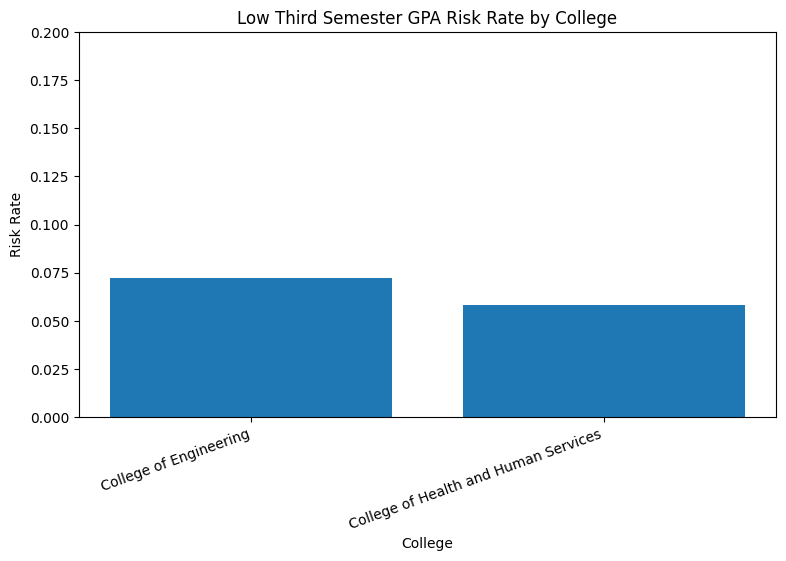

In [9]:
plot_data = college_summary.reset_index()

plt.figure(figsize=(9, 5))
plt.bar(plot_data['COLLEGE_GROUP'], plot_data['low_gpa_risk_rate'])
plt.title('Low Third Semester GPA Risk Rate by College')
plt.ylabel('Risk Rate')
plt.xlabel('College')
plt.xticks(rotation=20, ha='right')
plt.ylim(0, max(plot_data['low_gpa_risk_rate'].max() + 0.10, 0.20))
plt.show()


#### **Step 7: Define Feature Sets**

Create two feature sets for the model comparison. The regular feature set uses academic and demographic information, while the survey-enhanced feature set adds survey and text-derived variables. Outcome-related columns are excluded to prevent data leakage.

In [10]:
TARGET_COL = 'LOW_GPA_RISK'

leakage_keywords = [
    'SEM_3',
    'SEM3',
    'THIRD_SEM',
    'THIRD_SEMESTER'
]

base_exclude_cols = {
    TARGET_COL,
    gpa_col,
    college_col,
    'COLLEGE_GROUP'
}

regular_feature_cols = []
for col in train.columns:
    if col in test.columns and col not in base_exclude_cols:
        is_leakage = any(keyword in col.upper() for keyword in leakage_keywords)
        if not is_leakage:
            regular_feature_cols.append(col)

survey_feature_cols = []
for col in survey_train.columns:
    if col in survey_test.columns and col not in base_exclude_cols:
        is_leakage = any(keyword in col.upper() for keyword in leakage_keywords)
        if not is_leakage:
            survey_feature_cols.append(col)

print('Number of regular features:', len(regular_feature_cols))
print('Number of survey-enhanced features:', len(survey_feature_cols))

print('\nRegular feature preview:')
print(regular_feature_cols[:15])

print('\nSurvey-enhanced feature preview:')
print(survey_feature_cols[:15])


Number of regular features: 24
Number of survey-enhanced features: 52

Regular feature preview:
['SID', 'COHORT', 'RACE_ETHNICITY', 'GENDER', 'FIRST_GEN_STATUS', 'HS_GPA', 'HS_MATH_GPA', 'HS_ENGL_GPA', 'UNITS_ATTEMPTED_1', 'UNITS_ATTEMPTED_2', 'UNITS_ATTEMPTED_3', 'UNITS_COMPLETED_1', 'UNITS_COMPLETED_2', 'UNITS_COMPLETED_3', 'DFW_UNITS_1']

Survey-enhanced feature preview:
['HS_GPA', 'GPA_1', 'GPA_2', 'DFW_RATE_1', 'DFW_RATE_2', 'UNITS_ATTEMPTED_1', 'UNITS_ATTEMPTED_2', 'GENDER_Female', 'GENDER_Male', 'RACE_ETHNICITY_Asian', 'RACE_ETHNICITY_Black or African American', 'RACE_ETHNICITY_Hispanic', 'RACE_ETHNICITY_Nonresident alien', 'RACE_ETHNICITY_Other', 'RACE_ETHNICITY_Two or More Races']


#### **Step 8: Prepare Modeling Matrices**

Separate the feature columns from the target variable and build preprocessing pipelines for the regular and survey-enhanced datasets. Numeric features are imputed and scaled, while categorical features are imputed and one-hot encoded so all models receive machine-readable inputs.

In [11]:
X_train_regular = train[regular_feature_cols].copy()
X_test_regular = test[regular_feature_cols].copy()

y_train = train[TARGET_COL].copy()
y_test = test[TARGET_COL].copy()

X_train_survey = survey_train[survey_feature_cols].copy()
X_test_survey = survey_test[survey_feature_cols].copy()

test_college_groups = test['COLLEGE_GROUP'].copy()

print('Regular feature matrix:', X_train_regular.shape, X_test_regular.shape)
print('Survey-enhanced feature matrix:', X_train_survey.shape, X_test_survey.shape)
print('Target vector:', y_train.shape, y_test.shape)


Regular feature matrix: (6827, 24) (1776, 24)
Survey-enhanced feature matrix: (6827, 52) (1776, 52)
Target vector: (6827,) (1776,)


In [12]:
def build_preprocessor(X):
    numeric_features = X.select_dtypes(include=['number', 'bool']).columns.tolist()
    categorical_features = X.select_dtypes(exclude=['number', 'bool']).columns.tolist()

    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('numeric', numeric_transformer, numeric_features),
            ('categorical', categorical_transformer, categorical_features)
        ]
    )

    return preprocessor

regular_preprocessor = build_preprocessor(X_train_regular)
survey_preprocessor = build_preprocessor(X_train_survey)

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
scale_pos_weight = negative_count / max(positive_count, 1)

print('Positive class weight for XGBoost:', round(scale_pos_weight, 3))


Positive class weight for XGBoost: 14.446


# Analyze

In this section, you will train four classification models and compare their ability to predict low third semester GPA risk.


#### **Step 9: Train Logistic Regression, Decision Tree, XGBoost, and XGBoost with Survey Data**

Train the four required classification models. Logistic Regression provides a clear baseline, the Decision Tree adds an interpretable tree-based model, XGBoost adds a stronger boosted-tree model, and the final XGBoost model tests whether survey data improves prediction.

In [13]:
models = {
    'Logistic Regression': {
        'feature_set': 'regular',
        'model': Pipeline(steps=[
            ('preprocess', regular_preprocessor),
            ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))
        ])
    },
    'Decision Tree': {
        'feature_set': 'regular',
        'model': Pipeline(steps=[
            ('preprocess', regular_preprocessor),
            ('classifier', DecisionTreeClassifier(
                max_depth=5,
                min_samples_leaf=20,
                class_weight='balanced',
                random_state=RANDOM_STATE
            ))
        ])
    },
    'XGBoost': {
        'feature_set': 'regular',
        'model': Pipeline(steps=[
            ('preprocess', regular_preprocessor),
            ('classifier', XGBClassifier(
                n_estimators=100,
                learning_rate=0.05,
                max_depth=3,
                subsample=0.80,
                colsample_bytree=0.80,
                scale_pos_weight=scale_pos_weight,
                eval_metric='logloss',
                random_state=RANDOM_STATE,
                n_jobs=1
            ))
        ])
    },
    'XGBoost + Survey Data': {
        'feature_set': 'survey',
        'model': Pipeline(steps=[
            ('preprocess', survey_preprocessor),
            ('classifier', XGBClassifier(
                n_estimators=100,
                learning_rate=0.05,
                max_depth=3,
                subsample=0.80,
                colsample_bytree=0.80,
                scale_pos_weight=scale_pos_weight,
                eval_metric='logloss',
                random_state=RANDOM_STATE,
                n_jobs=1
            ))
        ])
    }
}

for model_name, model_info in models.items():
    if model_info['feature_set'] == 'regular':
        X_train_current = X_train_regular
    else:
        X_train_current = X_train_survey

    model_info['model'].fit(X_train_current, y_train)
    print(f'Trained: {model_name}')


Trained: Logistic Regression
Trained: Decision Tree
Trained: XGBoost
Trained: XGBoost + Survey Data


#### **Step 10: Evaluate Overall Model Performance**

Compare model performance on the testing data using accuracy, precision, recall, F1 score, ROC-AUC, and average precision. These metrics show both overall correctness and how well each model identifies students with low GPA risk.

In [14]:
def get_feature_matrix(model_info, split='test'):
    if model_info['feature_set'] == 'regular':
        return X_test_regular if split == 'test' else X_train_regular
    return X_test_survey if split == 'test' else X_train_survey


def evaluate_model(model_name, model_info):
    model = model_info['model']
    X_current = get_feature_matrix(model_info, split='test')

    y_prob = model.predict_proba(X_current)[:, 1]
    y_pred = (y_prob >= 0.50).astype(int)

    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1 Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'Average Precision': average_precision_score(y_test, y_prob)
    }

results = [evaluate_model(model_name, model_info) for model_name, model_info in models.items()]
results_df = pd.DataFrame(results).set_index('Model').sort_values('ROC-AUC', ascending=False)
results_df.round(3)


,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Average Precision
Model,,,,,,
Logistic Regression,0.988,0.853,1.000,0.921,1.000,1.000
XGBoost,0.979,0.771,0.992,0.867,0.999,0.994
Decision Tree,0.979,0.771,0.992,0.867,0.992,0.901
XGBoost + Survey Data,0.757,0.180,0.713,0.287,0.822,0.238


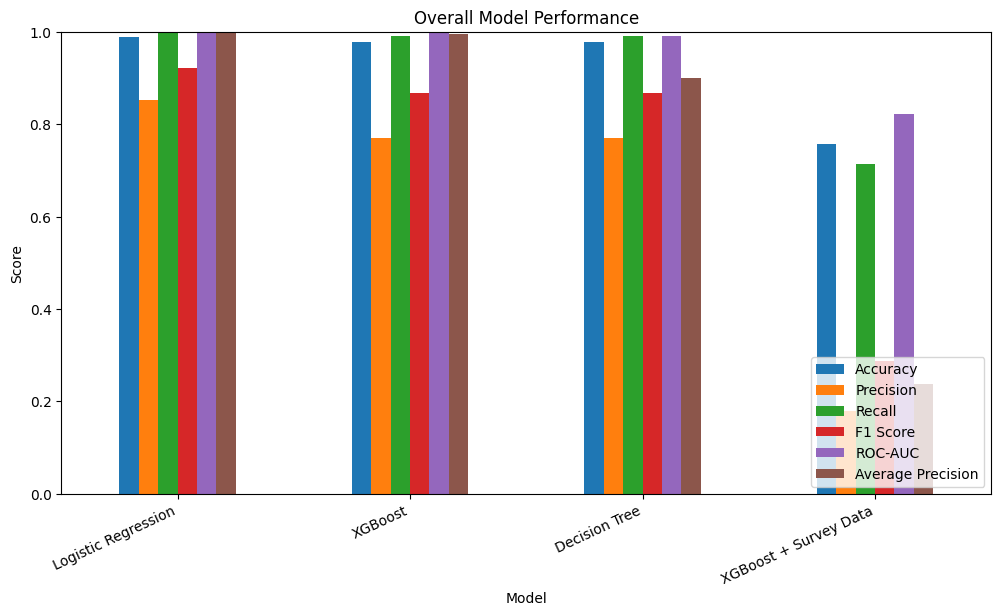

In [15]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC', 'Average Precision']

results_df[metrics_to_plot].plot(kind='bar', figsize=(12, 6))
plt.title('Overall Model Performance')
plt.ylabel('Score')
plt.xlabel('Model')
plt.xticks(rotation=25, ha='right')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.show()


In [16]:
for model_name, model_info in models.items():
    X_current = get_feature_matrix(model_info, split='test')
    y_pred = model_info['model'].predict(X_current)

    print('\n' + '=' * 70)
    print(model_name)
    print('=' * 70)
    print(classification_report(y_test, y_pred, target_names=['Not Low GPA Risk', 'Low GPA Risk'], zero_division=0))



Logistic Regression
                  precision    recall  f1-score   support

Not Low GPA Risk       1.00      0.99      0.99      1654
    Low GPA Risk       0.85      1.00      0.92       122

        accuracy                           0.99      1776
       macro avg       0.93      0.99      0.96      1776
    weighted avg       0.99      0.99      0.99      1776


Decision Tree
                  precision    recall  f1-score   support

Not Low GPA Risk       1.00      0.98      0.99      1654
    Low GPA Risk       0.77      0.99      0.87       122

        accuracy                           0.98      1776
       macro avg       0.89      0.99      0.93      1776
    weighted avg       0.98      0.98      0.98      1776


XGBoost
                  precision    recall  f1-score   support

Not Low GPA Risk       1.00      0.98      0.99      1654
    Low GPA Risk       0.77      0.99      0.87       122

        accuracy                           0.98      1776
       macro avg   

#### **Step 11: Compare Confusion Matrices**

Use confusion matrices to examine correct and incorrect predictions for each model. This view is especially useful for seeing whether a model is missing students who are actually in the low GPA risk group.

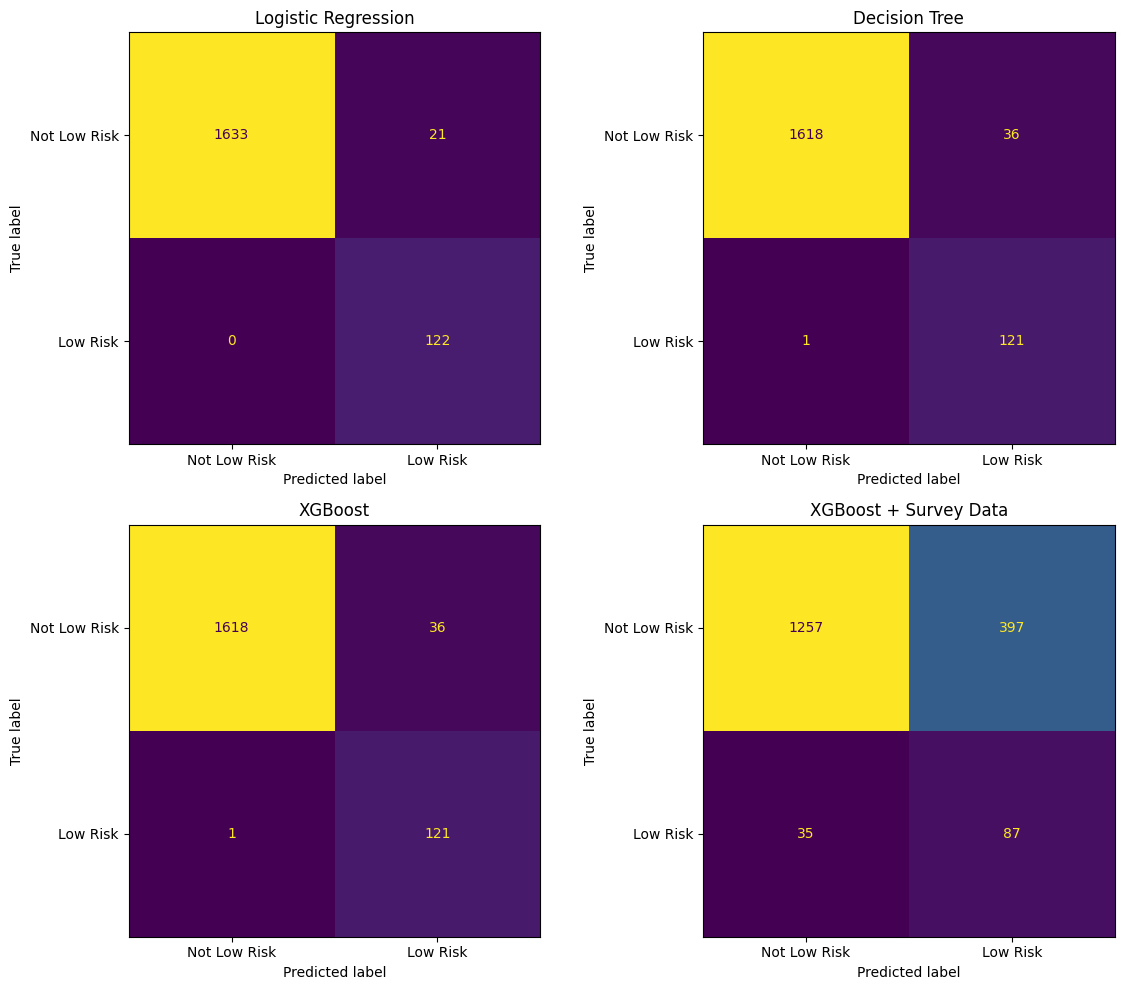

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, (model_name, model_info) in zip(axes, models.items()):
    X_current = get_feature_matrix(model_info, split='test')
    y_pred = model_info['model'].predict(X_current)
    cm = confusion_matrix(y_test, y_pred)

    display_cm = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Not Low Risk', 'Low Risk']
    )
    display_cm.plot(ax=ax, values_format='d', colorbar=False)
    ax.set_title(model_name)

plt.tight_layout()
plt.show()


#### **Step 12: Compare ROC and Precision-Recall Curves**

Review probability-based model performance across different thresholds. ROC curves show class separation, while precision-recall curves are helpful when the risk group is smaller than the non-risk group.

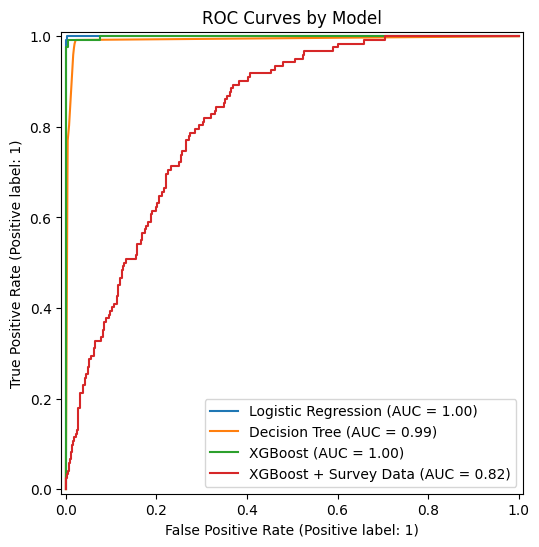

In [18]:
plt.figure(figsize=(9, 6))
ax = plt.gca()

for model_name, model_info in models.items():
    X_current = get_feature_matrix(model_info, split='test')
    y_prob = model_info['model'].predict_proba(X_current)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_prob, name=model_name, ax=ax)

plt.title('ROC Curves by Model')
plt.show()


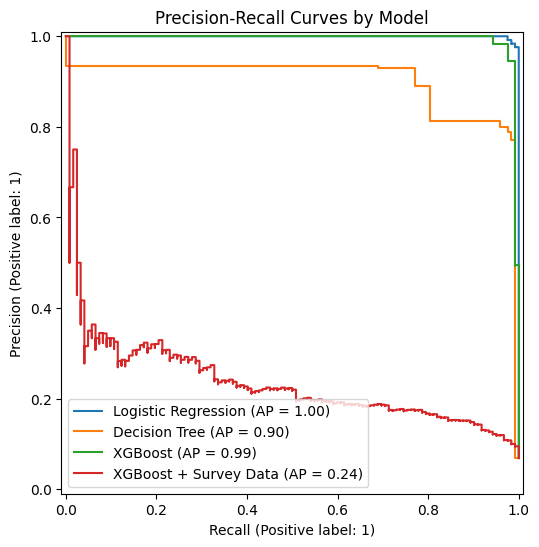

In [19]:
plt.figure(figsize=(9, 6))
ax = plt.gca()

for model_name, model_info in models.items():
    X_current = get_feature_matrix(model_info, split='test')
    y_prob = model_info['model'].predict_proba(X_current)[:, 1]
    PrecisionRecallDisplay.from_predictions(y_test, y_prob, name=model_name, ax=ax)

plt.title('Precision-Recall Curves by Model')
plt.show()


#### **Step 13: Compare Performance by College**

Evaluate each model separately for the two colleges. A model may perform well overall but still perform differently for each college, so college-level recall, F1 score, and ROC-AUC are reviewed side by side.

In [20]:
def college_metrics(model_name, model_info):
    X_current = get_feature_matrix(model_info, split='test')
    y_prob = model_info['model'].predict_proba(X_current)[:, 1]
    y_pred = (y_prob >= 0.50).astype(int)

    metric_rows = []
    for college in sorted(test_college_groups.unique()):
        mask = test_college_groups == college
        y_true_group = y_test[mask]
        y_pred_group = y_pred[mask]
        y_prob_group = y_prob[mask]

        roc_auc = np.nan
        average_precision = np.nan
        if y_true_group.nunique() == 2:
            roc_auc = roc_auc_score(y_true_group, y_prob_group)
            average_precision = average_precision_score(y_true_group, y_prob_group)

        metric_rows.append({
            'Model': model_name,
            'College': college,
            'Students': int(mask.sum()),
            'Low GPA Risk Rate': y_true_group.mean(),
            'Accuracy': accuracy_score(y_true_group, y_pred_group),
            'Precision': precision_score(y_true_group, y_pred_group, zero_division=0),
            'Recall': recall_score(y_true_group, y_pred_group, zero_division=0),
            'F1 Score': f1_score(y_true_group, y_pred_group, zero_division=0),
            'ROC-AUC': roc_auc,
            'Average Precision': average_precision
        })

    return pd.DataFrame(metric_rows)

college_results = pd.concat(
    [college_metrics(model_name, model_info) for model_name, model_info in models.items()],
    ignore_index=True
)

college_results.round(3)


,Model,College,Students,Low GPA Risk Rate,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Average Precision
0,Logistic Regression,College of Engineering,826,0.068,0.990,0.875,1.000,0.933,1.000,1.000
1,Logistic Regression,College of Health and Human Services,950,0.069,0.986,0.835,1.000,0.910,1.000,1.000
2,Decision Tree,College of Engineering,826,0.068,0.977,0.747,1.000,0.855,0.995,0.908
3,Decision Tree,College of Health and Human Services,950,0.069,0.981,0.793,0.985,0.878,0.989,0.896
4,XGBoost,College of Engineering,826,0.068,0.978,0.757,1.000,0.862,1.000,0.998
5,XGBoost,College of Health and Human Services,950,0.069,0.980,0.783,0.985,0.872,0.999,0.992
6,XGBoost + Survey Data,College of Engineering,826,0.068,0.736,0.173,0.768,0.283,0.826,0.251
7,XGBoost + Survey Data,College of Health and Human Services,950,0.069,0.775,0.186,0.667,0.291,0.822,0.244


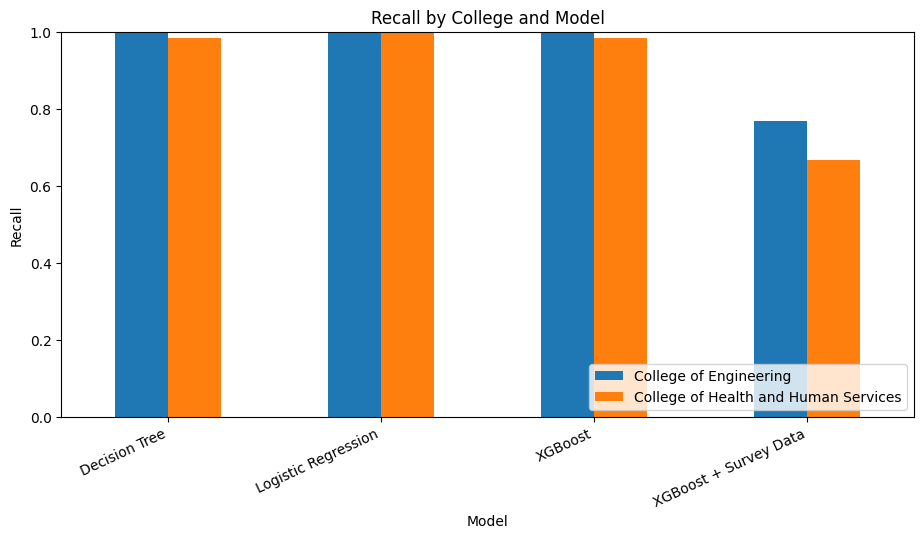

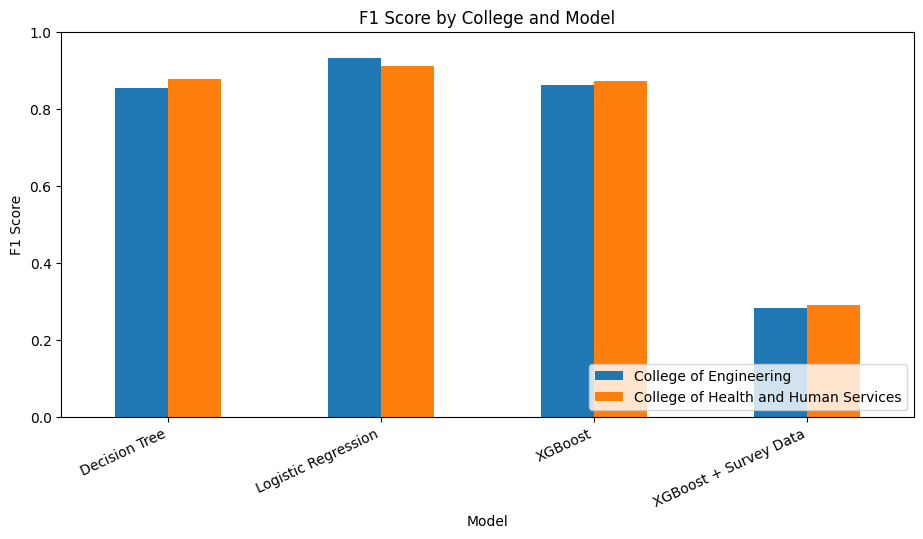

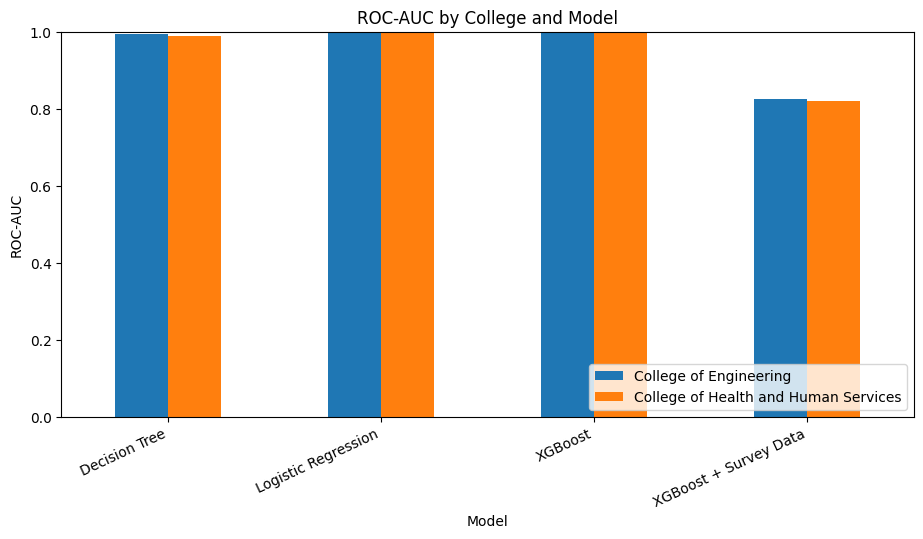

In [21]:
for metric in ['Recall', 'F1 Score', 'ROC-AUC']:
    pivot_table = college_results.pivot(index='Model', columns='College', values=metric)

    pivot_table.plot(kind='bar', figsize=(11, 5))
    plt.title(f'{metric} by College and Model')
    plt.ylabel(metric)
    plt.xlabel('Model')
    plt.xticks(rotation=25, ha='right')
    plt.ylim(0, 1)
    plt.legend(loc='lower right')
    plt.show()


#### **Step 14: Measure the Impact of Survey Data**

Compare XGBoost with and without survey-enhanced features. The goal is to determine whether survey data improves overall performance and whether it changes performance patterns for the two colleges.

In [22]:
survey_comparison = pd.DataFrame({
    'XGBoost': results_df.loc['XGBoost'],
    'XGBoost + Survey Data': results_df.loc['XGBoost + Survey Data']
}).T

survey_comparison.loc['Survey Impact'] = survey_comparison.loc['XGBoost + Survey Data'] - survey_comparison.loc['XGBoost']
survey_comparison.round(3)


,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Average Precision
XGBoost,0.979,0.771,0.992,0.867,0.999,0.994
XGBoost + Survey Data,0.757,0.180,0.713,0.287,0.822,0.238
Survey Impact,-0.222,-0.591,-0.279,-0.580,-0.177,-0.756


In [23]:
xgb_college = college_results[college_results['Model'].isin(['XGBoost', 'XGBoost + Survey Data'])]

survey_college_impact = (
    xgb_college
    .pivot(index='College', columns='Model', values=['Recall', 'F1 Score', 'ROC-AUC'])
)

survey_college_impact.round(3)


Recall                       F1 Score  \
Model                                XGBoost XGBoost + Survey Data  XGBoost   
College                                                                       
College of Engineering                 1.000                 0.768    0.862   
College of Health and Human Services   0.985                 0.667    0.872   

                                                           ROC-AUC  \
Model                                XGBoost + Survey Data XGBoost   
College                                                              
College of Engineering                               0.283   1.000   
College of Health and Human Services                 0.291   0.999   

                                                            
Model                                XGBoost + Survey Data  
College                                                     
College of Engineering                               0.826  
College of Health and Human Services                 0.822

#### **Step 15: Examine Feature Importance**

Review the strongest features used by the XGBoost models. Feature importance can help explain which inputs are contributing to predictions, but the results should be interpreted carefully and combined with domain knowledge.

In [24]:
def get_feature_names(pipeline):
    preprocessor = pipeline.named_steps['preprocess']
    return preprocessor.get_feature_names_out()


def get_xgb_feature_importance(model_name, top_n=15):
    pipeline = models[model_name]['model']
    classifier = pipeline.named_steps['classifier']
    feature_names = get_feature_names(pipeline)

    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': classifier.feature_importances_
    })

    importance_df = importance_df.sort_values('Importance', ascending=False).head(top_n)
    return importance_df

xgb_importance = get_xgb_feature_importance('XGBoost', top_n=15)
xgb_survey_importance = get_xgb_feature_importance('XGBoost + Survey Data', top_n=15)

xgb_importance


,Feature,Importance
18,numeric__GRADE_POINTS_3,0.404377
11,numeric__DFW_UNITS_3,0.201290
8,numeric__UNITS_COMPLETED_3,0.075303
5,numeric__UNITS_ATTEMPTED_3,0.067869
6836,categorical__COHORT_Fall 2019,0.029636
7,numeric__UNITS_COMPLETED_2,0.024496
17,numeric__GRADE_POINTS_2,0.019409
12,numeric__GPA_1,0.017509
6,numeric__UNITS_COMPLETED_1,0.014456
6849,categorical__FIRST_GEN_STATUS_First Generation,0.014097


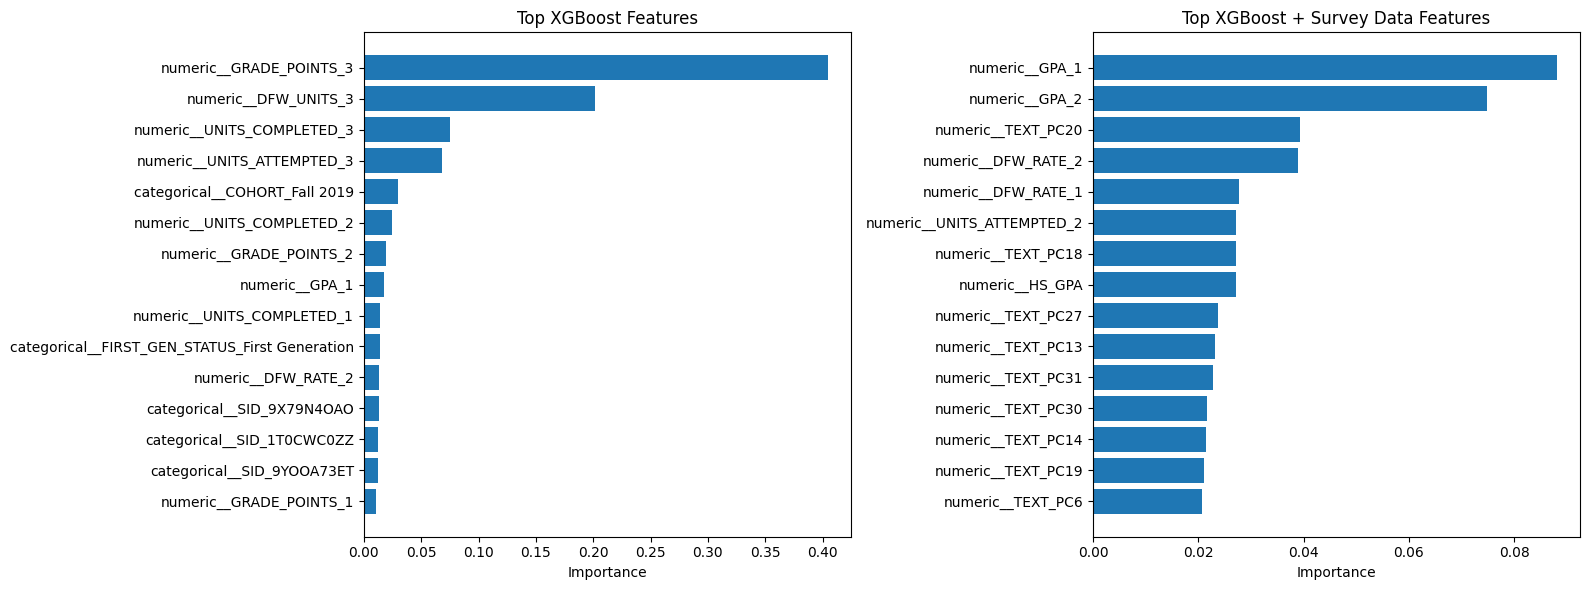

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(xgb_importance['Feature'][::-1], xgb_importance['Importance'][::-1])
axes[0].set_title('Top XGBoost Features')
axes[0].set_xlabel('Importance')

axes[1].barh(xgb_survey_importance['Feature'][::-1], xgb_survey_importance['Importance'][::-1])
axes[1].set_title('Top XGBoost + Survey Data Features')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()


#### **Step 16: Select a Model for Academic Support Planning**

Select a model using a combined ranking of ROC-AUC, recall, and F1 score. The selected model is then used to estimate low GPA risk probabilities and create risk tiers that can support academic planning discussions.

In [26]:
model_selection_table = results_df.copy()
model_selection_table['Rank by ROC-AUC'] = model_selection_table['ROC-AUC'].rank(ascending=False, method='min').astype(int)
model_selection_table['Rank by Recall'] = model_selection_table['Recall'].rank(ascending=False, method='min').astype(int)
model_selection_table['Rank by F1'] = model_selection_table['F1 Score'].rank(ascending=False, method='min').astype(int)
model_selection_table['Average Rank'] = model_selection_table[['Rank by ROC-AUC', 'Rank by Recall', 'Rank by F1']].mean(axis=1)
model_selection_table = model_selection_table.sort_values('Average Rank')

model_selection_table.round(3)


,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Average Precision,Rank by ROC-AUC,Rank by Recall,Rank by F1,Average Rank
Model,,,,,,,,,,
Logistic Regression,0.988,0.853,1.000,0.921,1.000,1.000,1,1,1,1.000
XGBoost,0.979,0.771,0.992,0.867,0.999,0.994,2,2,2,2.000
Decision Tree,0.979,0.771,0.992,0.867,0.992,0.901,3,2,2,2.333
XGBoost + Survey Data,0.757,0.180,0.713,0.287,0.822,0.238,4,4,4,4.000


In [27]:
selected_model_name = model_selection_table.index[0]
selected_model_info = models[selected_model_name]
selected_model = selected_model_info['model']
selected_X_test = get_feature_matrix(selected_model_info, split='test')

selected_probabilities = selected_model.predict_proba(selected_X_test)[:, 1]

risk_output = test[[college_col, 'COLLEGE_GROUP', gpa_col, TARGET_COL]].copy()
risk_output['Predicted Low GPA Risk Probability'] = selected_probabilities
risk_output['Risk Tier'] = pd.cut(
    risk_output['Predicted Low GPA Risk Probability'],
    bins=[-0.01, 0.33, 0.66, 1.00],
    labels=['Lower Risk', 'Moderate Risk', 'Higher Risk']
)

print('Selected model:', selected_model_name)
risk_output.head(10)


Selected model: Logistic Regression


,COLLEGE,COLLEGE_GROUP,GPA_3,LOW_GPA_RISK,Predicted Low GPA Risk Probability,Risk Tier
6,Health & Human Services,College of Health and Human Services,3.000000,0,3.622168e-05,Lower Risk
9,Health & Human Services,College of Health and Human Services,3.833333,0,7.540308e-13,Lower Risk
11,Health & Human Services,College of Health and Human Services,4.000000,0,1.921993e-05,Lower Risk
15,Engineering & Technology,College of Engineering,3.333333,0,7.259816e-07,Lower Risk
16,Engineering & Technology,College of Engineering,3.200000,0,1.761553e-07,Lower Risk
21,Engineering & Technology,College of Engineering,3.333333,0,6.826071e-08,Lower Risk
25,Health & Human Services,College of Health and Human Services,3.333333,0,1.010634e-07,Lower Risk
28,Health & Human Services,College of Health and Human Services,3.250000,0,7.692792e-08,Lower Risk
29,Engineering & Technology,College of Engineering,2.846154,0,9.852644e-05,Lower Risk
35,Health & Human Services,College of Health and Human Services,4.000000,0,1.682528e-09,Lower Risk


In [28]:
risk_tier_summary = (
    risk_output
    .groupby(['COLLEGE_GROUP', 'Risk Tier'])
    .agg(
        students=(TARGET_COL, 'size'),
        observed_low_gpa_risk_rate=(TARGET_COL, 'mean'),
        average_predicted_probability=('Predicted Low GPA Risk Probability', 'mean')
    )
    .reset_index()
)

risk_tier_summary['observed_low_gpa_risk_rate'] = risk_tier_summary['observed_low_gpa_risk_rate'].round(3)
risk_tier_summary['average_predicted_probability'] = risk_tier_summary['average_predicted_probability'].round(3)

risk_tier_summary


,COLLEGE_GROUP,Risk Tier,students,observed_low_gpa_risk_rate,average_predicted_probability
0,College of Engineering,Lower Risk,756,0.000,0.007
1,College of Engineering,Moderate Risk,12,0.000,0.497
2,College of Engineering,Higher Risk,58,0.966,0.973
3,College of Health and Human Services,Lower Risk,863,0.000,0.005
4,College of Health and Human Services,Moderate Risk,13,0.000,0.459
5,College of Health and Human Services,Higher Risk,74,0.892,0.951


## Part 2: Unsupervised Learning Extension

Supervised models predict a known outcome. Unsupervised learning looks for structure in the data without using the outcome label. In this section, K-Means clustering is used to explore student support profiles using the survey-enhanced feature set.


#### **Step 17: Use K-Means to Identify Student Support Profiles**

Use K-Means clustering to explore student support profiles without using the GPA risk label. This unsupervised learning section helps students think about patterns that may exist in the data beyond the supervised prediction task.

In [29]:
cluster_preprocessor = build_preprocessor(X_train_survey)
cluster_matrix = cluster_preprocessor.fit_transform(X_train_survey)

if hasattr(cluster_matrix, 'toarray'):
    cluster_matrix = cluster_matrix.toarray()

cluster_scores = []
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(cluster_matrix)
    score = silhouette_score(cluster_matrix, labels)
    cluster_scores.append({'k': k, 'Silhouette Score': score})

cluster_scores_df = pd.DataFrame(cluster_scores)
cluster_scores_df


,k,Silhouette Score
0,2,0.101456
1,3,0.038971
2,4,0.031639
3,5,0.053971
4,6,0.038753


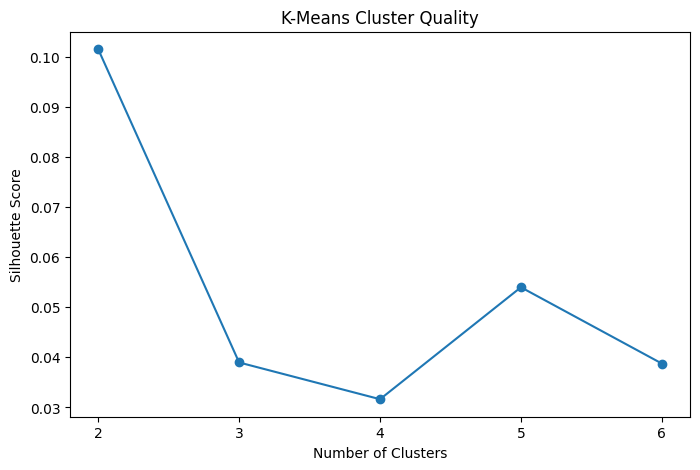

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(cluster_scores_df['k'], cluster_scores_df['Silhouette Score'], marker='o')
plt.title('K-Means Cluster Quality')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.xticks(cluster_scores_df['k'])
plt.show()


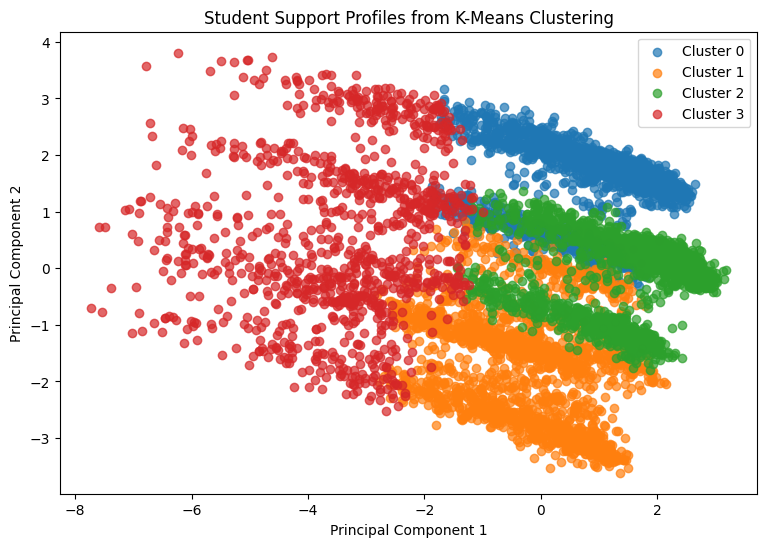

In [31]:
selected_k = 4

kmeans = KMeans(n_clusters=selected_k, random_state=RANDOM_STATE, n_init=10)
clusters = kmeans.fit_predict(cluster_matrix)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
cluster_embedding = pca.fit_transform(cluster_matrix)

cluster_plot_df = pd.DataFrame({
    'PC1': cluster_embedding[:, 0],
    'PC2': cluster_embedding[:, 1],
    'Cluster': clusters.astype(str),
    'College': train['COLLEGE_GROUP'].values,
    'Low GPA Risk': y_train.values
})

plt.figure(figsize=(9, 6))
for cluster_label in sorted(cluster_plot_df['Cluster'].unique()):
    cluster_subset = cluster_plot_df[cluster_plot_df['Cluster'] == cluster_label]
    plt.scatter(cluster_subset['PC1'], cluster_subset['PC2'], label=f'Cluster {cluster_label}', alpha=0.7)

plt.title('Student Support Profiles from K-Means Clustering')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()


#### **Step 18: Profile the Clusters**

Summarize each cluster by observed GPA outcomes and college representation. These summaries help interpret whether certain student profiles have higher academic risk or different college distributions.

In [32]:
cluster_profile = train[['COLLEGE_GROUP', gpa_col, TARGET_COL]].copy()
cluster_profile['Cluster'] = clusters

cluster_summary = (
    cluster_profile
    .groupby('Cluster')
    .agg(
        students=(TARGET_COL, 'size'),
        average_third_semester_gpa=(gpa_col, 'mean'),
        low_gpa_risk_rate=(TARGET_COL, 'mean')
    )
)

cluster_summary['average_third_semester_gpa'] = cluster_summary['average_third_semester_gpa'].round(3)
cluster_summary['low_gpa_risk_rate'] = cluster_summary['low_gpa_risk_rate'].round(3)

cluster_summary


,students,average_third_semester_gpa,low_gpa_risk_rate
Cluster,,,
0,1929,3.250,0.048
1,1945,3.206,0.062
2,1903,3.431,0.028
3,1050,2.741,0.167


In [33]:
cluster_college_distribution = pd.crosstab(
    cluster_profile['Cluster'],
    cluster_profile['COLLEGE_GROUP'],
    normalize='index'
).round(3)

cluster_college_distribution


COLLEGE_GROUP,College of Engineering,College of Health and Human Services
Cluster,,
0,0.730,0.270
1,0.452,0.548
2,0.216,0.784
3,0.490,0.510


### Reflection Questions: Unsupervised Learning

1. Which clusters have the highest observed low GPA risk rate?
2. Are the two colleges represented similarly across the clusters?
3. What types of advising, tutoring, or outreach might be appropriate for each cluster?
4. How is clustering different from the supervised prediction models used earlier?
5. What cautions should be considered before using clusters to guide student support decisions?


# Deploy

In this section, you will summarize the model comparison results and translate the analysis into recommendations for academic support planning.


#### **Step 19: Generate a Final Summary Table**

Bring together the main model comparison results and the college-level performance results. These tables provide the evidence needed for the final recommendation.

In [34]:
final_summary = results_df.copy()
final_summary['Selected Model'] = final_summary.index == selected_model_name
final_summary.round(3)


,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Average Precision,Selected Model
Model,,,,,,,
Logistic Regression,0.988,0.853,1.000,0.921,1.000,1.000,True
XGBoost,0.979,0.771,0.992,0.867,0.999,0.994,False
Decision Tree,0.979,0.771,0.992,0.867,0.992,0.901,False
XGBoost + Survey Data,0.757,0.180,0.713,0.287,0.822,0.238,False


In [35]:
college_gap_summary = college_results.copy()
college_gap_summary['College Comparison Key'] = college_gap_summary['Model'] + ' - ' + college_gap_summary['College']
college_gap_summary[['Model', 'College', 'Students', 'Low GPA Risk Rate', 'Recall', 'F1 Score', 'ROC-AUC']].round(3)


,Model,College,Students,Low GPA Risk Rate,Recall,F1 Score,ROC-AUC
0,Logistic Regression,College of Engineering,826,0.068,1.000,0.933,1.000
1,Logistic Regression,College of Health and Human Services,950,0.069,1.000,0.910,1.000
2,Decision Tree,College of Engineering,826,0.068,1.000,0.855,0.995
3,Decision Tree,College of Health and Human Services,950,0.069,0.985,0.878,0.989
4,XGBoost,College of Engineering,826,0.068,1.000,0.862,1.000
5,XGBoost,College of Health and Human Services,950,0.069,0.985,0.872,0.999
6,XGBoost + Survey Data,College of Engineering,826,0.068,0.768,0.283,0.826
7,XGBoost + Survey Data,College of Health and Human Services,950,0.069,0.667,0.291,0.822


#### **Step 20: Produce a Capstone Report**

Use the completed analysis to write a concise report for academic leaders. The report should connect the prediction goal, model comparison, college-level findings, survey-data impact, clustering insights, and final recommendation.

## Capstone Report: Third Semester GPA Risk Prediction

### 1. Prediction Goal

The goal of this project is to predict whether students from the College of Health and Human Services and the College of Engineering are at risk of earning a third semester GPA below 2.0 after completing their first year.

### 2. Model Comparison

Summarize how Logistic Regression, Decision Tree, XGBoost, and XGBoost with survey data performed. Include the strongest model based on ROC-AUC, recall, and F1 score.

### 3. College Comparison

Compare model performance for the College of Health and Human Services and the College of Engineering. Discuss whether the selected model performs consistently across both colleges.

### 4. Survey Data Impact

Explain whether adding survey-enhanced features improved prediction performance. Include both overall performance and college-specific performance.

### 5. Unsupervised Learning Insights

Describe what the clustering analysis suggests about student support profiles. Explain how these clusters could help academic support teams design better interventions.

### 6. Recommendation

Recommend one model for academic support planning and explain how the model output should be used responsibly. Include at least two practical intervention ideas based on the analysis.
